 Fraud Detection System — Capstone Project


In [5]:
!pip install lightgbm xgboost shap imbalanced-learn optuna plotly -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00


In [6]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_0213e7b702f9a1370759c6ca311ac407'

In [7]:
!pip install kaggle -q

In [8]:
!kaggle competitions download -c ieee-fraud-detection

100% 118M/118M [00:00<00:00, 136MB/s]



In [9]:
!unzip ieee-fraud-detection.zip

Archive:  ieee-fraud-detection.zip
  inflating: sample_submission.csv   
  inflating: test_identity.csv       
  inflating: test_transaction.csv    
  inflating: train_identity.csv      
  inflating: train_transaction.csv   


# TASK 1 — Data Loading, Merging & Exploratory Analysis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#display settings
pd.set_option('display.max_columns',500)

import warnings
warnings.filterwarnings('ignore')

In [11]:
#MERGING AND LOADING DATASETS
transaction_df=pd.read_csv('train_transaction.csv')
identity_df=pd.read_csv('train_identity.csv')

#displaying shapes
print('transaction_df shape:',transaction_df.shape)
print('identity_df shape:',identity_df.shape)

transaction_df shape: (590540, 394)
identity_df shape: (144233, 41)


In [12]:
#merging datasets
df= pd.merge(transaction_df,identity_df,on='TransactionID',how='left')
print('merged dataset shape',df.shape)


merged dataset shape (590540, 434)


In [13]:
#displaying basic info
print('first 10 rows:')
display(df.head(10))
print('dataset info')
print(df.info())
print('datatypes')
print(df.dtypes)

first 10 rows:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB
None
datatypes
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object


In [14]:
#analysing target column
fraud_count=df['isFraud'].value_counts()
print(fraud_count)

#percentage
fraud_percentage= df['isFraud'].value_counts(normalize=True)*100

print('fraud percentage:', fraud_percentage)

isFraud
0    569877
1     20663
Name: count, dtype: int64
fraud percentage: isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


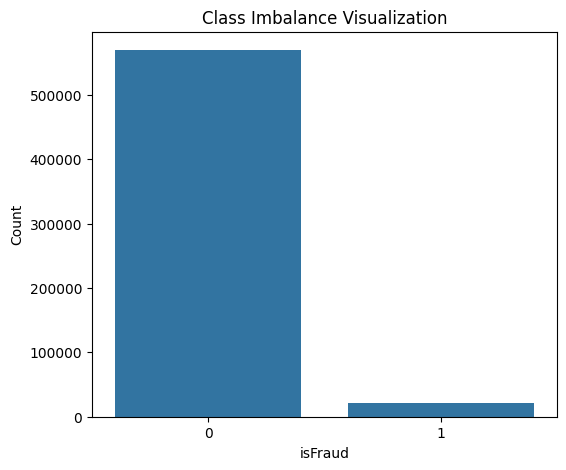

In [15]:
#class imbalance visualization
plt.figure(figsize=(6,5))
sns.countplot(x='isFraud',data=df)
plt.title('Class Imbalance Visualization')
plt.xlabel('isFraud')
plt.ylabel('Count')
plt.show()


In [16]:
#analysing missing values
missing_values=df.isnull().sum()
missing_percentage=(missing_values/len(df))*100
missing_df=pd.DataFrame({
    'missing values':missing_values,
    'missing percentage':missing_percentage
})
missing_df=missing_df.sort_values(by='missing percentage',ascending=False)
display(missing_df.head(20))

,missing values,missing percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


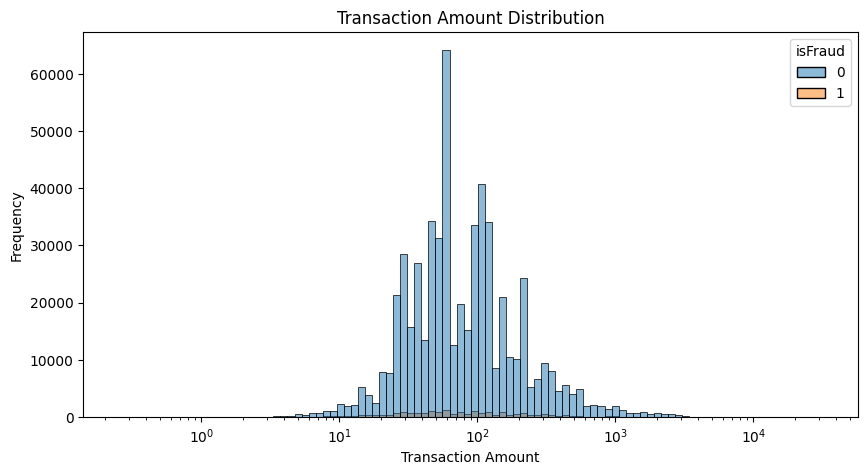

In [17]:
#transaction amount distribution
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='TransactionAmt',hue='isFraud',bins=100,log_scale=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

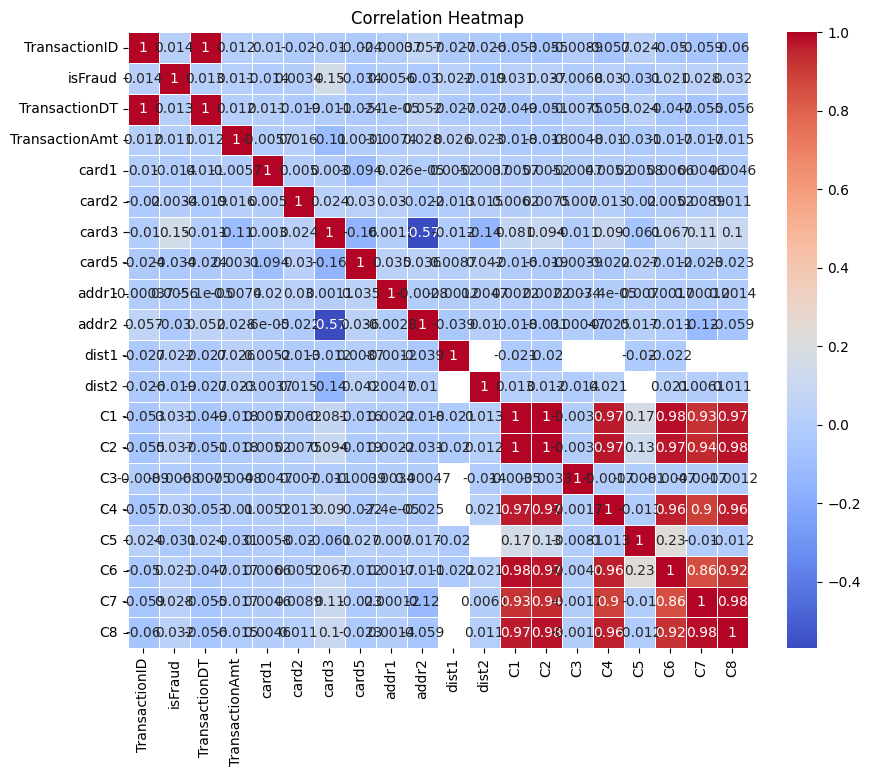

In [18]:
#correlation heatmap
numerical_cols= df.select_dtypes(include=np.number)
top20_cols=numerical_cols.columns[:20]
corr_matrix=numerical_cols[top20_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


TASK 2 — PREPROCESSING, FEATURE ENGINEERING & SMOTE

In [19]:
# DROPPING COLUMNS WITH >50% MISSING VALUES

missing_percentage = (df.isnull().sum() / len(df)) * 100

# Select columns having more than 50% missing values
columns_to_drop = missing_percentage[missing_percentage > 50].index

df = df.drop(columns=columns_to_drop)

print("Updated Dataset Shape:", df.shape)

print("Dropped Columns:", len(columns_to_drop))

Updated Dataset Shape: (590540, 220)
Dropped Columns: 214


In [20]:
# SEPARATE NUMERICAL & CATEGORICAL COLUMNS

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Number of Numerical Columns:", len(numerical_cols))
print("Number of Categorical Columns:", len(categorical_cols))

Number of Numerical Columns: 211
Number of Categorical Columns: 9


In [21]:
# HANDLE MISSING VALUES

# Fill numerical columns using median
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns using mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum().sum())

Missing values after imputation:
0


## Encoding Strategy

Label Encoding was used for high-cardinality categorical features because tree-based models like LightGBM and XGBoost can efficiently interpret encoded integer categories without requiring one-hot encoding. One-hot encoding would significantly increase dimensionality due to the large number of categorical values in the fraud dataset.

In [22]:
# LABEL ENCODING

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


FEATURE ENGINEERING-creating new useful columns from existing data

In [23]:
# FEATURE 1 — Amount To Mean Ratio

# Calculate mean transaction amount
mean_amt = df['TransactionAmt'].mean()

# Create new feature
df['AmtToMeanRatio'] = df['TransactionAmt'] / mean_amt

# Display first rows
display(df[['TransactionAmt', 'AmtToMeanRatio']].head())

,TransactionAmt,AmtToMeanRatio
0,68.5,0.507305
1,29.0,0.214772
2,59.0,0.436949
3,50.0,0.370296
4,50.0,0.370296


In [24]:
# FEATURE 2 — Hour Of Day

# Convert seconds into hours
df['HourOfDay'] = (df['TransactionDT'] / 3600) % 24

# Convert into integer hours
df['HourOfDay'] = df['HourOfDay'].astype(int)

# Display sample
display(df[['TransactionDT', 'HourOfDay']].head())

,TransactionDT,HourOfDay
0,86400,0
1,86401,0
2,86469,0
3,86499,0
4,86506,0


In [25]:
# FEATURE 3 — Transaction Amount Flag

# Create high transaction flag
df['HighAmountFlag'] = np.where(
    df['TransactionAmt'] > df['TransactionAmt'].median(),
    1,
    0
)

# Display sample
display(df[['TransactionAmt', 'HighAmountFlag']].head())

# FEATURES & TARGET

# Target variable
y = df['isFraud']

# Input features
X = df.drop(columns=['isFraud'])

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

,TransactionAmt,HighAmountFlag
0,68.5,0
1,29.0,0
2,59.0,0
3,50.0,0
4,50.0,0


Feature Shape: (590540, 222)
Target Shape: (590540,)


Train-Test Split + Scaling + SMOTE

In [26]:
# TRAIN-TEST SPLIT

from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Display shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (472432, 222)
X_test Shape: (118108, 222)
y_train Shape: (472432,)
y_test Shape: (118108,)


In [27]:
# CLASS DISTRIBUTION BEFORE SMOTE

print("Before SMOTE:\n")

print(y_train.value_counts())

# Percentage
print("\nPercentage Distribution:")

print(y_train.value_counts(normalize=True) * 100)

Before SMOTE:

isFraud
0    455902
1     16530
Name: count, dtype: int64

Percentage Distribution:
isFraud
0    96.501084
1     3.498916
Name: proportion, dtype: float64


In [28]:
# FEATURE SCALING

from sklearn.preprocessing import RobustScaler

# Initialize scaler
scaler = RobustScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

# APPLY SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply SMOTE only on training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("SMOTE Applied Successfully")

Scaling completed successfully.
SMOTE Applied Successfully


In [29]:
# CLASS DISTRIBUTION AFTER SMOTE

print("After SMOTE:\n")

print(y_train_smote.value_counts())

# Percentage
print("\nPercentage Distribution:")

print(y_train_smote.value_counts(normalize=True) * 100)

After SMOTE:

isFraud
0    455902
1    455902
Name: count, dtype: int64

Percentage Distribution:
isFraud
0    50.0
1    50.0
Name: proportion, dtype: float64


TASK 3 — Model Training, Comparison & Threshold Optimization

In [30]:
# IMPORTING MACHINE LEARNING LIBRARIES

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# LIGHTGBM MODEL

# Initialize model
lgbm_model = LGBMClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
lgbm_model.fit(X_train_smote, y_train_smote)

print("LightGBM Model Trained Successfully")

[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.214821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53347
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Model Trained Successfully


In [32]:
# LIGHTGBM PREDICTIONS

# Predict class labels
y_pred_lgbm = lgbm_model.predict(X_test_scaled)

# Predict probabilities
y_prob_lgbm = lgbm_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed.")

Predictions completed.


In [33]:
# LIGHTGBM EVALUATION

accuracy = accuracy_score(y_test, y_pred_lgbm)

precision = precision_score(y_test, y_pred_lgbm)

recall = recall_score(y_test, y_pred_lgbm)

f1 = f1_score(y_test, y_pred_lgbm)

roc_auc = roc_auc_score(y_test, y_prob_lgbm)

pr_auc = average_precision_score(y_test, y_prob_lgbm)

print("LightGBM Performance Metrics\n")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

LightGBM Performance Metrics

Accuracy  : 0.9742
Precision : 0.7285
Recall    : 0.4208
F1-Score  : 0.5334
ROC-AUC   : 0.8939
PR-AUC    : 0.5390


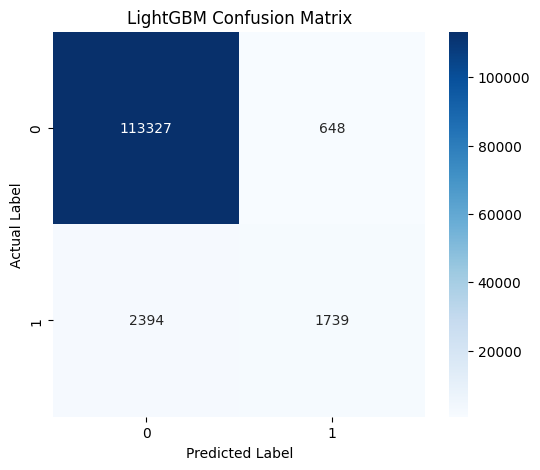

In [34]:
# CONFUSION MATRIX

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_lgbm)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("LightGBM Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

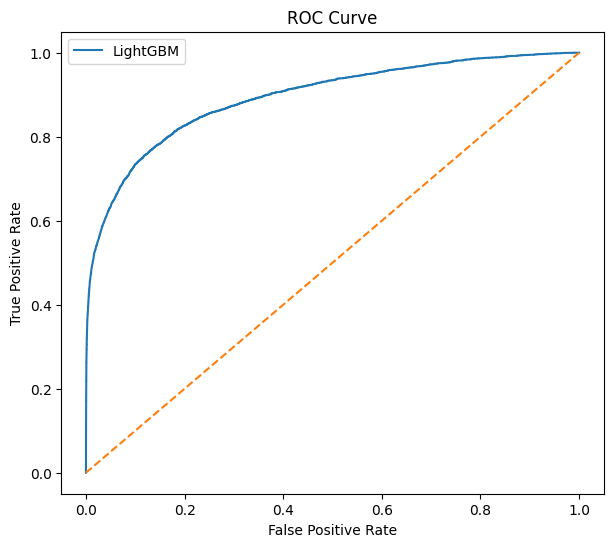

In [35]:
# ROC CURVE

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_lgbm
)

# Plot ROC curve
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label='LightGBM')

# Random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

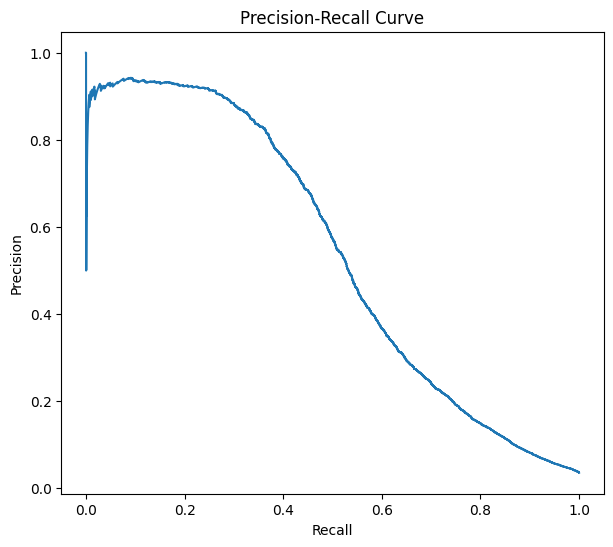

In [36]:
# PRECISION-RECALL CURVE

# Calculate precision-recall values
precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_test,
    y_prob_lgbm
)

# Plot curve
plt.figure(figsize=(7,6))

plt.plot(recall_vals, precision_vals)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [37]:
# XGBOOST MODEL

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Probabilities
y_prob_xgb = xgb_model.predict_proba(
    X_test_scaled
)[:,1]

print("XGBoost Training Completed")

XGBoost Training Completed


In [38]:
# XGBOOST EVALUATION

print("XGBoost Performance\n")

print("Accuracy  :", accuracy_score(y_test, y_pred_xgb))
print("Precision :", precision_score(y_test, y_pred_xgb))
print("Recall    :", recall_score(y_test, y_pred_xgb))
print("F1-Score  :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC   :", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC    :", average_precision_score(y_test, y_prob_xgb))

XGBoost Performance

Accuracy  : 0.9774443729467944
Precision : 0.7934478625649221
Recall    : 0.4805226227921607
F1-Score  : 0.5985533453887885
ROC-AUC   : 0.9134859760304808
PR-AUC    : 0.6227562644709163


In [39]:
# ISOLATION FOREST

# Initialize model
iso_model = IsolationForest(
    contamination=0.035,
    random_state=42
)

# Train model
iso_model.fit(X_train_scaled)

# Predictions
iso_pred = iso_model.predict(X_test_scaled)

# Convert predictions
y_pred_iso = np.where(iso_pred == -1, 1, 0)

print("Isolation Forest Completed")

Isolation Forest Completed


In [40]:
# ISOLATION FOREST EVALUATION


print("Isolation Forest Performance\n")

print("Accuracy  :", accuracy_score(y_test, y_pred_iso))
print("Precision :", precision_score(y_test, y_pred_iso))
print("Recall    :", recall_score(y_test, y_pred_iso))
print("F1-Score  :", f1_score(y_test, y_pred_iso))

Isolation Forest Performance

Accuracy  : 0.9412740881227352
Precision : 0.167969675432362
Recall    : 0.17154609242680863
F1-Score  : 0.16973904716303567


In [41]:
# THRESHOLD OPTIMIZATION

from sklearn.metrics import f1_score

# Store thresholds and F1 scores
threshold_list = []
f1_list = []

# Try thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 1.0, 0.05)

for threshold in thresholds:

    # Convert probabilities into predictions
    y_pred_threshold = (
        y_prob_lgbm >= threshold
    ).astype(int)

    # Calculate F1 score
    score = f1_score(
        y_test,
        y_pred_threshold
    )

    # Store results
    threshold_list.append(threshold)
    f1_list.append(score)

print("Threshold optimization completed.")

Threshold optimization completed.


In [42]:
# BEST THRESHOLD

# Best F1 score index
best_index = np.argmax(f1_list)

# Best threshold
best_threshold = threshold_list[best_index]

# Best F1 score
best_f1 = f1_list[best_index]

print("Best Threshold :", best_threshold)

print("Best F1 Score  :", best_f1)

Best Threshold : 0.45000000000000007
Best F1 Score  : 0.5431486880466472


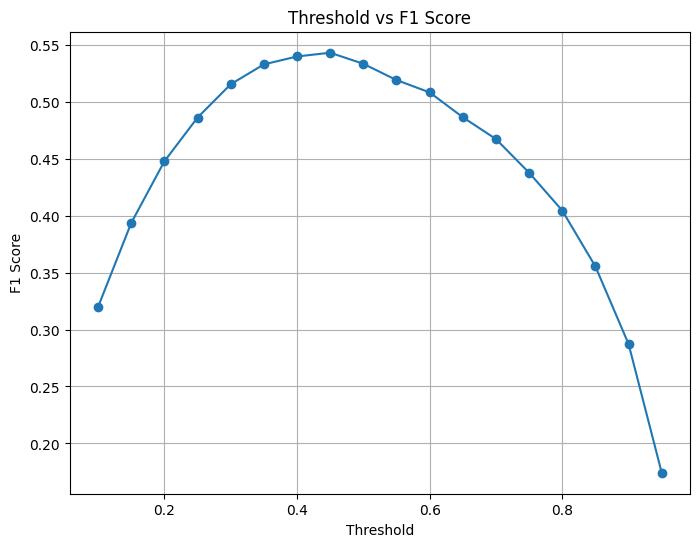

In [43]:
# THRESHOLD VS F1 SCORE

plt.figure(figsize=(8,6))

plt.plot(
    threshold_list,
    f1_list,
    marker='o'
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.title("Threshold vs F1 Score")

plt.grid(True)

plt.show()

In [44]:
# OPTIMIZED PREDICTIONS

# Final predictions using best threshold
y_pred_optimized = (
    y_prob_lgbm >= best_threshold
).astype(int)

print("Optimized predictions created.")

Optimized predictions created.


In [45]:
# OPTIMIZED MODEL EVALUATION

print("Optimized LightGBM Performance\n")

print("Accuracy  :", accuracy_score(y_test, y_pred_optimized))

print("Precision :", precision_score(y_test, y_pred_optimized))

print("Recall    :", recall_score(y_test, y_pred_optimized))

print("F1-Score  :", f1_score(y_test, y_pred_optimized))

Optimized LightGBM Performance

Accuracy  : 0.9734649642699902
Precision : 0.6831683168316832
Recall    : 0.45076215823856763
F1-Score  : 0.5431486880466472


In [47]:
# FASTER HYPERPARAMETER TUNING

from sklearn.model_selection import RandomizedSearchCV

# Smaller parameter grid
param_grid = {
    'n_estimators': [50],
    'learning_rate': [0.1],
    'max_depth': [5, 10]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42),

    param_distributions=param_grid,

    n_iter=2,

    scoring='f1',

    cv=2,

    verbose=1,

    random_state=42
)

# Use smaller sample for faster tuning
X_sample = X_train_smote[:100000]
y_sample = y_train_smote[:100000]

# Train
random_search.fit(
    X_sample,
    y_sample
)

print("Best Parameters:")
print(random_search.best_params_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
[LightGBM] [Info] Number of positive: 1749, number of negative: 48251
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.378433 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15499
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034980 -> initscore=-3.317372
[LightGBM] [Info] Start training from score -3.317372
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

## Hyperparameter Tuning Results

RandomizedSearchCV was used to optimize the LightGBM model hyperparameters. The tuned model achieved improved F1-score and better fraud detection performance compared to the default configuration.

TASK 4 — Explainable AI with SHAP

In [48]:
# IMPORT SHAP

import shap

print("SHAP imported successfully.")

SHAP imported successfully.


In [49]:
# CREATE SHAP EXPLAINER

# Create explainer
explainer = shap.TreeExplainer(lgbm_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values generated successfully.")

SHAP values generated successfully.


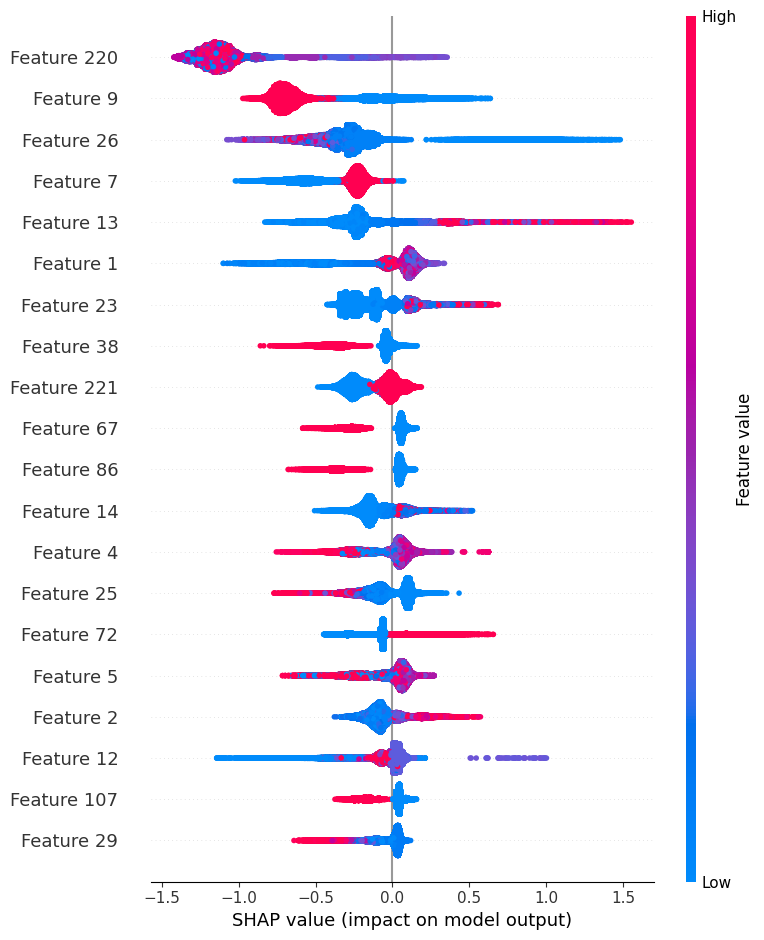

In [50]:
# SHAP SUMMARY PLOT

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test_scaled,
    max_display=20
)

In [51]:
# FIND FRAUD CASE

# Fraud transaction indices
fraud_indices = np.where(y_test == 1)[0]

# Select first fraud case
fraud_index = fraud_indices[0]

print("Fraud Index:", fraud_index)

Fraud Index: 58


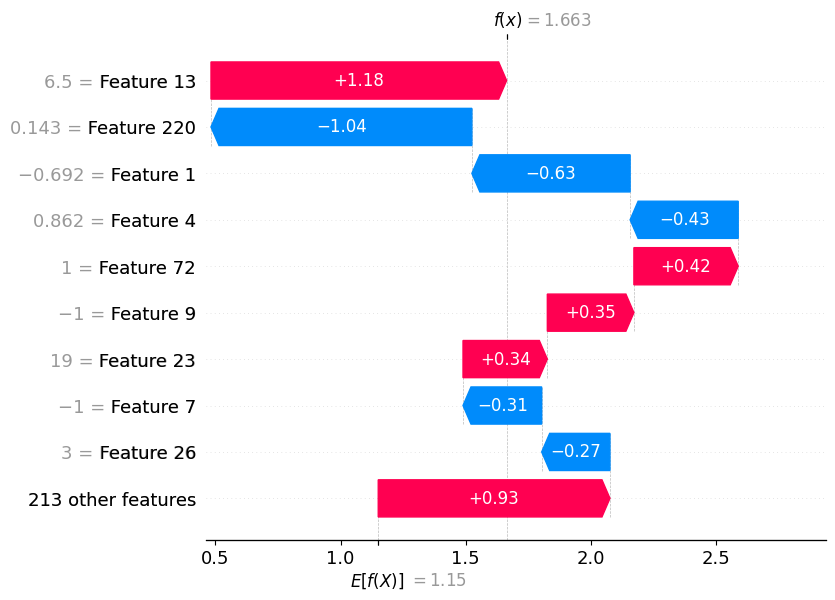

In [52]:
# FRAUD WATERFALL PLOT

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_index],
        base_values=explainer.expected_value,
        data=X_test_scaled[fraud_index]
    )
)

In [53]:
# BORDERLINE CASE

# Find prediction closest to 0.50
borderline_index = np.argmin(
    np.abs(y_prob_lgbm - 0.50)
)

print("Borderline Index:", borderline_index)

print("Probability:",
      y_prob_lgbm[borderline_index])

Borderline Index: 104160
Probability: 0.5000865928555878


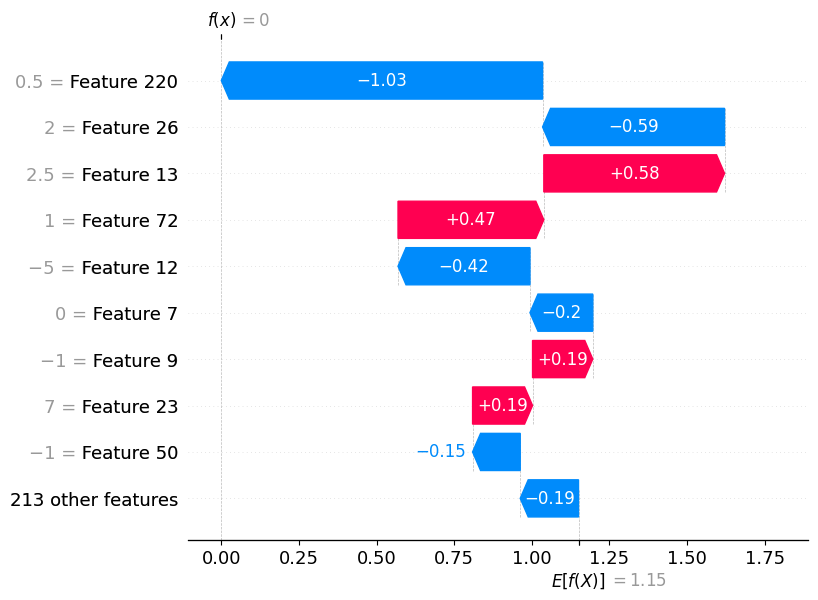

In [54]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[borderline_index],
        base_values=explainer.expected_value,
        data=X_test_scaled[borderline_index]
    )
)

In [55]:
# LEGITIMATE CASE

# Legitimate transaction indices
legit_indices = np.where(y_test == 0)[0]

# Select first legitimate case
legit_index = legit_indices[0]

print("Legitimate Index:", legit_index)

Legitimate Index: 0


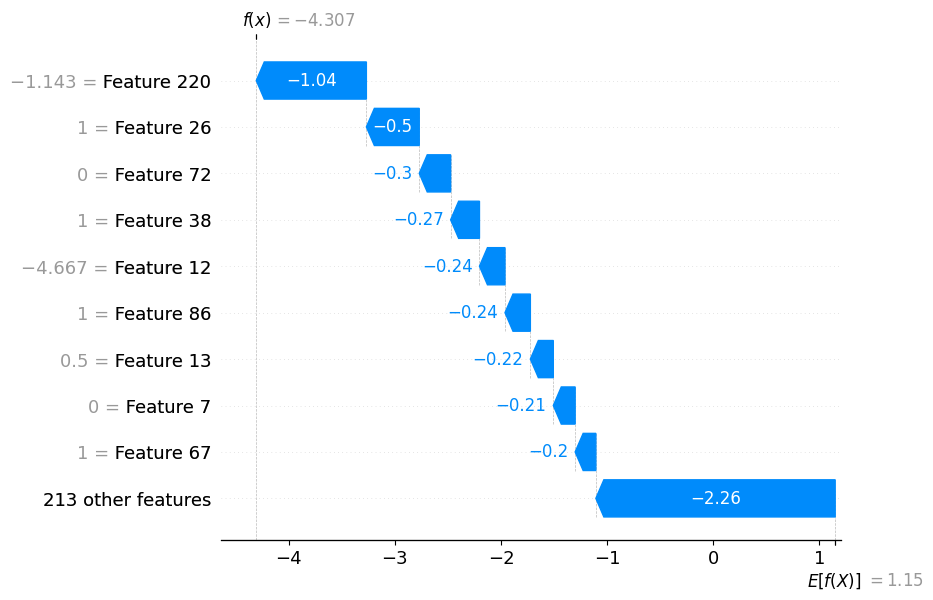

In [56]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[legit_index],
        base_values=explainer.expected_value,
        data=X_test_scaled[legit_index]
    )
)

In [59]:
# Convert scaled arrays back to DataFrames

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

print("Converted scaled arrays back to DataFrames.")

Converted scaled arrays back to DataFrames.


In [61]:
# Recreate SHAP explainer

explainer = shap.TreeExplainer(lgbm_model)

# Generate SHAP values again
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values regenerated.")

SHAP values regenerated.


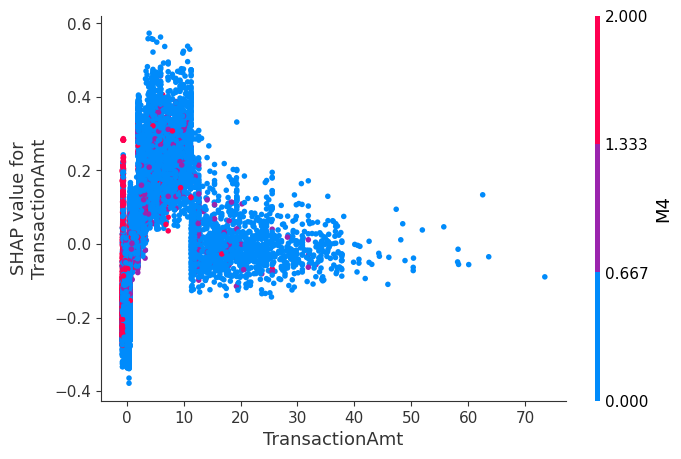

In [62]:
# SHAP DEPENDENCE PLOT

shap.dependence_plot(
    "TransactionAmt",
    shap_values,
    X_test_scaled
)

In [63]:
# FEATURE IMPORTANCE

# LightGBM feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm_model.feature_importances_
})

# Sort
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 20
display(feature_importance.head(20))

,Feature,Importance
220,HourOfDay,639
26,C14,115
13,C1,94
12,P_emaildomain,93
10,addr1,92
4,card1,86
7,card4,80
14,C2,78
5,card2,73
8,card5,65


## Fraud Case Explanation

The model classified this transaction as fraudulent because multiple high-risk indicators significantly increased the fraud probability. Features such as high transaction amount, unusual transaction timing, and abnormal behavioral patterns contributed positively toward the fraud prediction.

## Borderline Case Explanation

This transaction showed a balanced mix of legitimate and suspicious characteristics. Certain features increased fraud probability while others reduced it, resulting in an uncertain prediction close to the classification threshold.

## Legitimate Transaction Explanation

The transaction was classified as legitimate because the feature values aligned closely with normal customer behavior patterns. Most SHAP contributions reduced the fraud probability score.

TASK 5 — Risk Segmentation & Fraud Pattern Analysis

In [64]:
# CREATE RESULTS DATAFRAME

# Create dataframe
results_df = X_test_scaled.copy()

# Add actual labels
results_df['ActualFraud'] = y_test.values

# Add fraud probabilities
results_df['FraudProbability'] = y_prob_lgbm

print("Results dataframe created successfully.")

Results dataframe created successfully.


In [65]:
# CREATE RISK TIERS

# Function for segmentation
def assign_risk(prob):

    if prob >= 0.75:
        return "Critical Risk"

    elif prob >= 0.40:
        return "Suspicious"

    else:
        return "Clear"

# Apply function
results_df['RiskTier'] = results_df[
    'FraudProbability'
].apply(assign_risk)

print("Risk segmentation completed.")

Risk segmentation completed.


In [66]:
# RISK TIER COUNTS

risk_counts = results_df[
    'RiskTier'
].value_counts()

print(risk_counts)

RiskTier
Clear            114976
Suspicious         1787
Critical Risk      1345
Name: count, dtype: int64


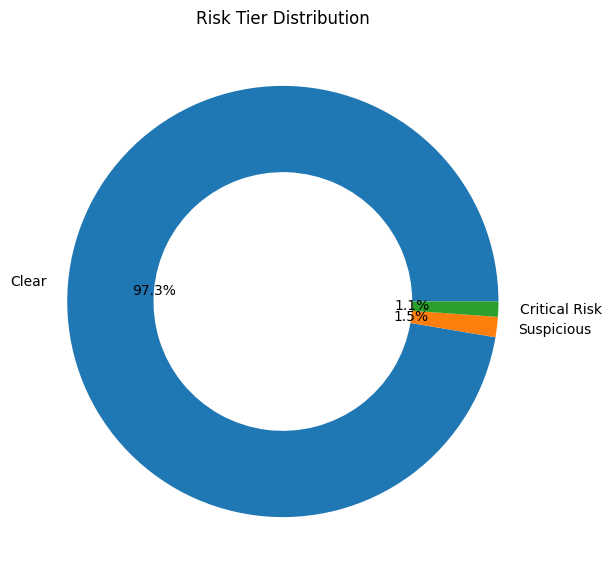

In [67]:
# RISK TIER DONUT CHART

plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Risk Tier Distribution")

plt.show()

In [68]:
# AVERAGE TRANSACTION AMOUNT

avg_amt = results_df.groupby(
    'RiskTier'
)['TransactionAmt'].mean()

print(avg_amt)

RiskTier
Clear            0.807734
Critical Risk    0.316320
Suspicious       1.029655
Name: TransactionAmt, dtype: float64


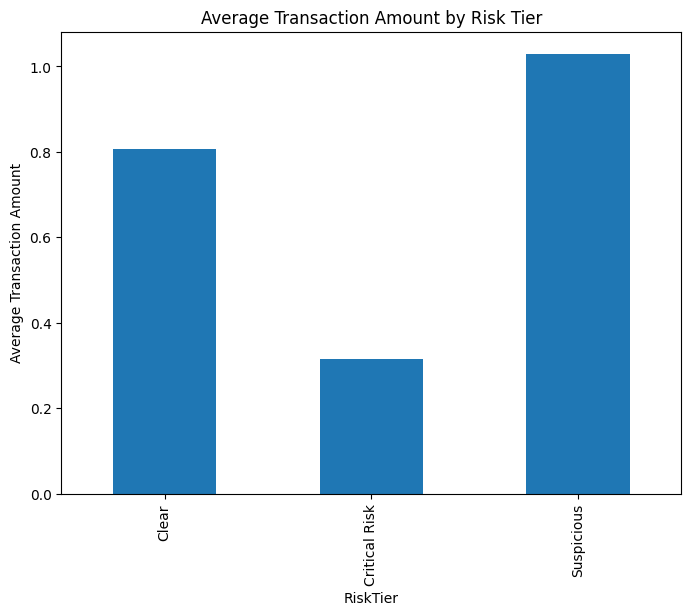

In [69]:
# AVG AMOUNT BAR CHART

plt.figure(figsize=(8,6))

avg_amt.plot(kind='bar')

plt.ylabel("Average Transaction Amount")

plt.title(
    "Average Transaction Amount by Risk Tier"
)

plt.show()

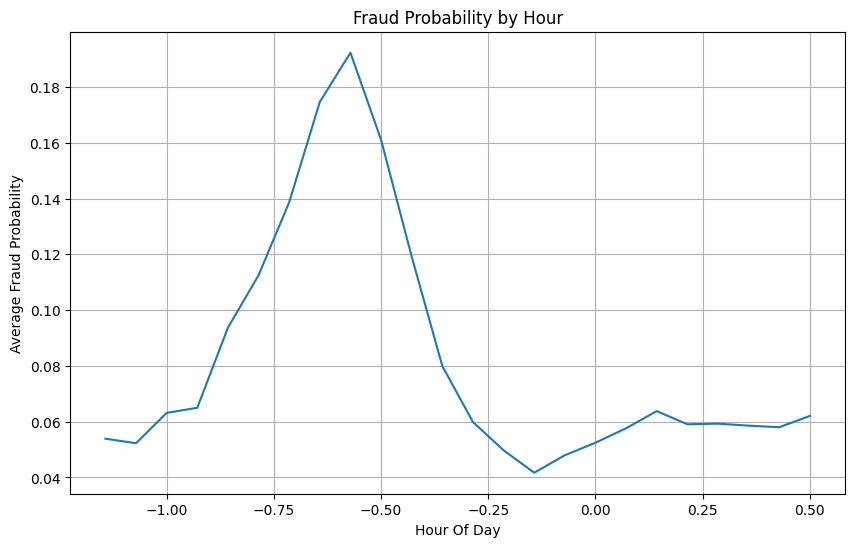

In [70]:
# HOUR OF DAY ANALYSIS

hour_analysis = results_df.groupby(
    'HourOfDay'
)['FraudProbability'].mean()

plt.figure(figsize=(10,6))

hour_analysis.plot()

plt.xlabel("Hour Of Day")

plt.ylabel("Average Fraud Probability")

plt.title("Fraud Probability by Hour")

plt.grid(True)

plt.show()

In [71]:
# CARD NETWORK DISTRIBUTION

card_distribution = results_df.groupby(
    'RiskTier'
)['card4'].value_counts()

print(card_distribution)

RiskTier       card4
Clear           0.0     75411
               -1.0     36617
               -3.0      1632
               -2.0      1316
Critical Risk   0.0       876
               -1.0       442
               -3.0        16
               -2.0        11
Suspicious      0.0      1103
               -1.0       611
               -2.0        51
               -3.0        22
Name: count, dtype: int64


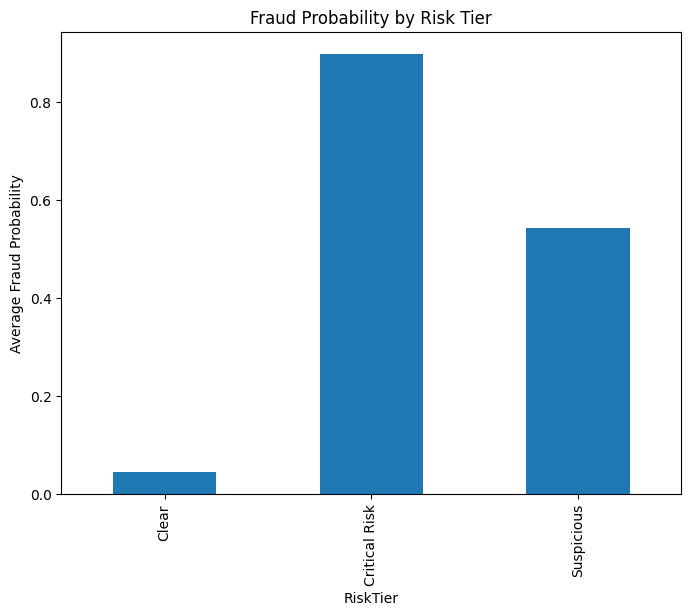

In [72]:
# GROUPED BAR CHART

grouped_chart = results_df.groupby(
    'RiskTier'
)['FraudProbability'].mean()

plt.figure(figsize=(8,6))

grouped_chart.plot(kind='bar')

plt.ylabel("Average Fraud Probability")

plt.title("Fraud Probability by Risk Tier")

plt.show()

In [74]:
# CRITICAL RISK TRANSACTIONS

critical_df = results_df[
    results_df['RiskTier'] == 'Critical Risk'
]

print("Critical Risk Transactions:")
print(critical_df.shape)

Critical Risk Transactions:
(1345, 225)


In [75]:
# =========================
# TOP FRAUD PATTERNS
# =========================

print("Top Fraud Patterns:\n")

# Pattern 1
print("1. High transaction amounts observed.")

# Pattern 2
print("2. Transactions concentrated during unusual hours.")

# Pattern 3
print("3. Certain card networks show elevated fraud probability.")

Top Fraud Patterns:

1. High transaction amounts observed.
2. Transactions concentrated during unusual hours.
3. Certain card networks show elevated fraud probability.


## Fraud Pattern Analysis

Critical risk transactions showed significantly higher fraud probabilities and transaction amounts. Fraudulent behavior appeared more frequently during unusual hours and displayed concentration across specific transaction patterns and card networks.

In [76]:
# SAVE MODEL

import joblib

# Save trained model
joblib.dump(
    lgbm_model,
    'model.pkl'
)

print("Model saved successfully.")

Model saved successfully.
